In [9]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

In [10]:
# ImageNet 표준 정규화 값
norm_mean = [0.485, 0.456, 0.406]
norm_std = [0.229, 0.224, 0.225]

# Train용 Transform: 데이터 증강
# 뇌종양 데이터여서 회전이나 반전이 매우 중요함
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(norm_mean, norm_std)
])

# Validation용 Transform: 정직하게 데이터 전처리만
# 검증 데이터에 Random 요소가 들어가면 매번 결과가 달라져서 성능 측정이 안됨
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(norm_mean, norm_std)
])

data_path = '/content/drive/MyDrive/Colab Notebooks/뇌종양 분류/Training'

full_dataset = datasets.ImageFolder(root=data_path)

# 인덱스 분리
train_idx, val_idx = train_test_split(
    list(range(len(full_dataset))),
    test_size=0.2,
    random_state=42,  # 시드 고정 안하면 재현 불가능
    shuffle=True
)

# 각각의 서브셋 생성 시 다른 transform 적용
train_data = Subset(datasets.ImageFolder(root=data_path, transform=train_transform), train_idx)
val_data = Subset(datasets.ImageFolder(root=data_path, transform=val_transform), val_idx)

# DataLoader 설정
# pin_memory=True: 메모리의 특정 구역을 고정해서 CPU에서 GPU로 데이터를 전송할 때 고속도로를 깔아주는 것과 같다. (데이터 로딩 속도가 빨라짐)
# 검증용은 순서대로 확인해야 하므로 shuffle=False가 기본
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=2)

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ResNet18 모델 로드
# weights='IMAGENET1K_V1'은 이미 1,000개의 사물을 구분하도록 학습된 모델 가져오기
# 데이터가 적을 때는 처음부터 가르치는 것보다 훨씬 효율적임
model = models.resnet18(weights='IMAGENET1K_V1')

# ResNet18의 원래 마지막(fc)은 1,000개 클래스용으로 뇌종양 4가지 종류에 맞게 4로 바꿔줘야 함
# model.fc.in_features: 이전 레이어에서 들어오는 입력 차원 수(512)를 자동으로 잡아준다.
model.fc = nn.Linear(model.fc.in_features, 4)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

# 학습률 스케줄러
# step_size=7, gamma=0.1: 7 에폭마다 학습률을 1/10로 줄이겠다라는 의미
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

In [12]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=10, patience=3, min_delta=0.001):
    best_acc = 0.0
    # 조기 종료를 추적하기 위한 트래커를 초기화
    best_acc_tracker = 0.0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    counter = 0
    early_stop = False

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                # 순전파: train일 때만 기울기를 계산하도록 설정
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs) # 모델에 데이터를 넣고 예측값 추출
                    _, preds = torch.max(outputs, 1)  # 가장 높은 확률을 가진 클래스 번호 선택
                    loss = criterion(outputs, labels) # 정답이랑 얼마나 다른지 계산

                    # 역전파 + 최적화
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # 검증(val) 페이즈 종료 시 조기 종료 로직 수행
            if phase == 'val':
                scheduler.step()

                if epoch_acc > (best_acc_tracker + min_delta):
                    print(f'Validation Acc: ({best_acc_tracker:.4f} --> {epoch_acc:.4f})')
                    best_acc_tracker = epoch_acc
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), 'best_brain_tumor_model.pth')
                    counter = 0 # 개선되었으니 카운터 초기화
                else:
                    counter += 1
                    print(f'EarlyStopping counter: {counter} out of {patience}')
                    if counter >= patience:
                        early_stop = True

        print('-' * 10)

        # 에폭 루프 가장 마지막에 체크하여 다음 에폭 진입을 막음
        if early_stop:
            print(f'Best Val Acc: {best_acc:.4f}')
            break

    return history

# 함수 호출 (patience와 min_delta를 넘겨줍니다)
history = train_model(model, criterion, optimizer, scheduler, num_epochs=10, patience=3, min_delta=0.001)

Epoch 1/10
Train Loss: 0.4591 Acc: 0.8262
Val Loss: 0.2154 Acc: 0.9321
Validation Acc: (0.0000 --> 0.9321)
----------
Epoch 2/10
Train Loss: 0.1662 Acc: 0.9399
Val Loss: 0.1254 Acc: 0.9599
Validation Acc: (0.9321 --> 0.9599)
----------
Epoch 3/10
Train Loss: 0.0925 Acc: 0.9726
Val Loss: 0.1375 Acc: 0.9582
EarlyStopping counter: 1 out of 3
----------
Epoch 4/10
Train Loss: 0.0539 Acc: 0.9839
Val Loss: 0.1419 Acc: 0.9460
EarlyStopping counter: 2 out of 3
----------
Epoch 5/10
Train Loss: 0.0742 Acc: 0.9726
Val Loss: 0.1113 Acc: 0.9669
Validation Acc: (0.9599 --> 0.9669)
----------
Epoch 6/10
Train Loss: 0.0353 Acc: 0.9904
Val Loss: 0.1235 Acc: 0.9599
EarlyStopping counter: 1 out of 3
----------
Epoch 7/10
Train Loss: 0.0296 Acc: 0.9917
Val Loss: 0.0882 Acc: 0.9704
Validation Acc: (0.9669 --> 0.9704)
----------
Epoch 8/10
Train Loss: 0.0219 Acc: 0.9939
Val Loss: 0.0808 Acc: 0.9686
EarlyStopping counter: 1 out of 3
----------
Epoch 9/10
Train Loss: 0.0147 Acc: 0.9961
Val Loss: 0.0707 Acc: 

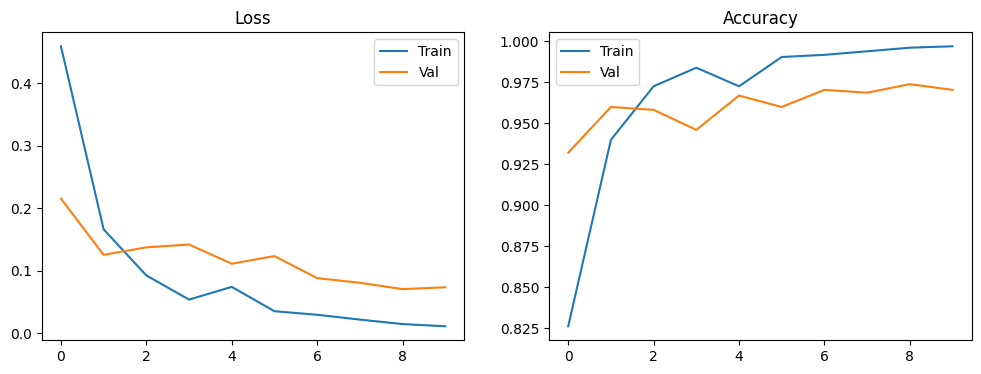

In [13]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train')
plt.plot(history['val_acc'], label='Val')
plt.title('Accuracy')
plt.legend()
plt.show()

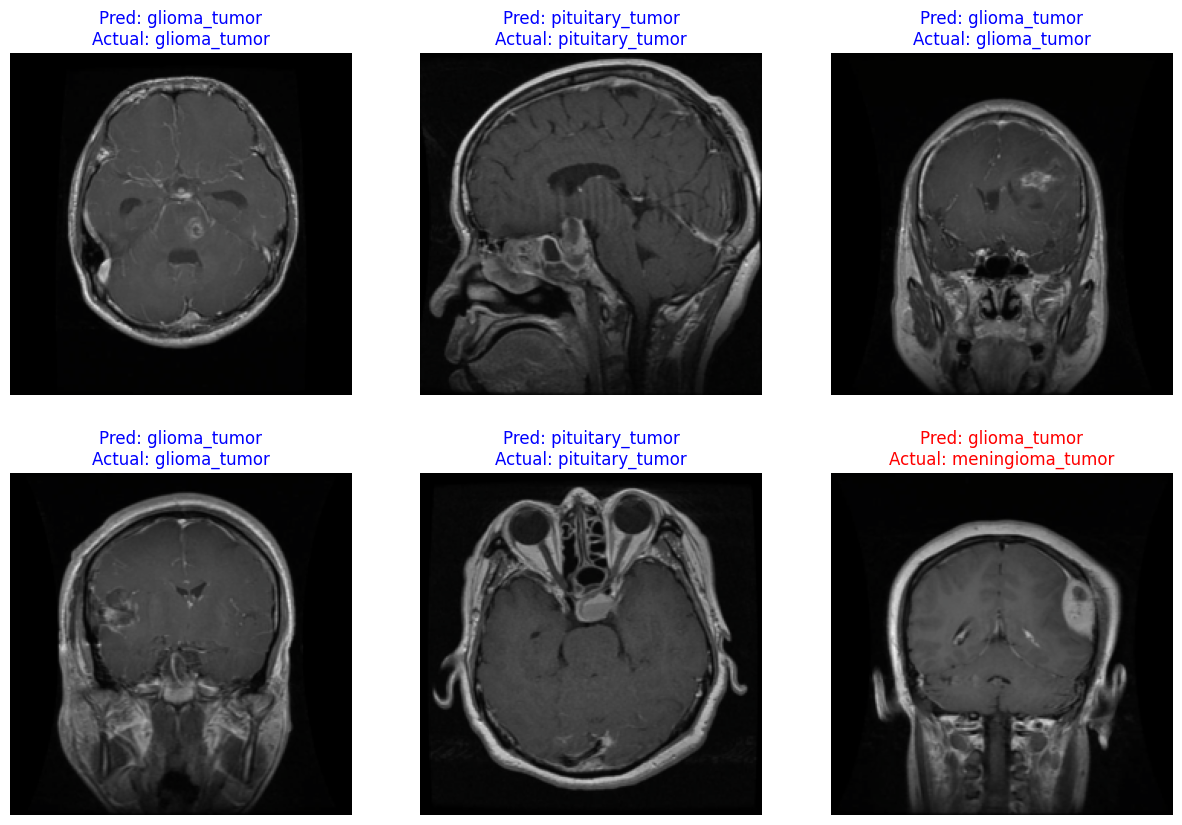

In [14]:
def visualize_predictions(model, dataloader, device, num_images=6):
  model.eval()
  images_so_far = 0
  plt.figure(figsize=(15, 10))

  class_names = full_dataset.classes

  with torch.no_grad():
    for i, (inputs, labels) in enumerate(dataloader):
      inputs = inputs.to(device)
      labels = labels.to(device)

      outputs = model(inputs)
      _, preds = torch.max(outputs, 1)

      for j in range(inputs.size()[0]):
        images_so_far += 1
        ax = plt.subplot(num_images // 3, 3, images_so_far)
        ax.axis('off')

        color = 'blue' if preds[j] == labels[j] else 'red'
        ax.set_title(f'Pred: {class_names[preds[j]]}\nActual: {class_names[labels[j]]}', color=color)

        img = inputs.cpu().data[j].numpy().transpose((1, 2, 0)) # (채널, 가로, 세로) -> (가로, 세로, 채널)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        plt.imshow(img)

        if images_so_far == num_images:
          return

visualize_predictions(model, val_loader, device)